In [35]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
experiments = [
    {"id": "exp_20250625_162425", "name": "Openwhisk"},
    {"id": "exp_20250625_113106", "name": "Proposed"},
    {"id": "exp_20250625_211541", "name": "Histogram"},
    {"id": "exp_20250626_050332", "name": "Pagurus"},
]

In [46]:
experiment_id = "exp_20250625_113106"
path = f"../results/{experiment_id}/results_updated.csv"
df = pd.read_csv(path)

In [47]:

def parse_json_safe(val):
    if pd.isna(val) or val == "None":
        return None
    if isinstance(val, dict):  # Already a dict
        return val
    try:
        return json.loads(val)
    except Exception:
        return None

def extract_name(res,name):
    if isinstance(res, dict):
        return res.get(name)
    return None




def extract_error_message(res):
    if isinstance(res, dict):
        resp = res.get("response", {})
        if not resp.get("success", True):
            return resp.get("result", {}).get("error")
    return None

def has_cuda_error(msg):
    if isinstance(msg, str):
        return "cuda" in msg.lower() or "cudnn" in msg.lower()
    return False

def extract_success(res):
    if isinstance(res, dict):
        return res.get("response", {}).get("success", True)
    return False

df["result_parsed"] = df["result"].apply(parse_json_safe)
df["name"] = df["result_parsed"].apply(lambda res: extract_name(res, "name"))
df['name'] = df['name'].str.replace(r'_p$', '', regex=True)
df["start"] = df["result_parsed"].apply(lambda res: extract_name(res, "start"))
df["end"] = df["result_parsed"].apply(lambda res: extract_name(res, "end"))
df['latency'] = df['end'] - df['start']
df["error_message"] = df["result_parsed"].apply(extract_error_message)
df["has_cuda_or_cudnn_error"] = df["error_message"].apply(has_cuda_error)
df["success"] = df["result_parsed"].apply(extract_success)
df["error"] = df["result_parsed"].isna() | (~df["success"])

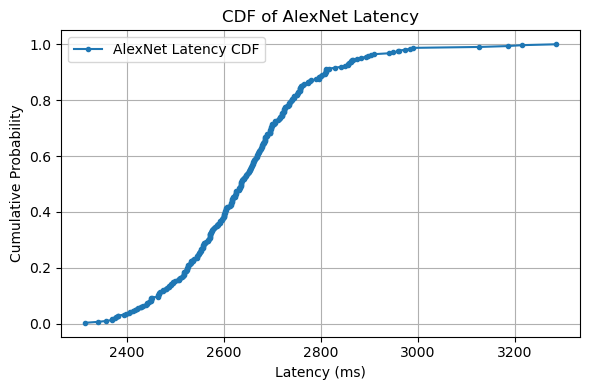

In [48]:
alexnet_df = df[df['name'] == 'resnet50']


# Filter latency values and sort them
latencies = alexnet_df['latency'].values
latencies_sorted = np.sort(latencies)
cdf = np.arange(1, len(latencies_sorted)+1) / len(latencies_sorted)

# Plot the CDF
plt.figure(figsize=(6, 4))
plt.plot(latencies_sorted, cdf, marker='.', linestyle='-', label='AlexNet Latency CDF')

plt.title('CDF of AlexNet Latency')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
